In [1]:
pip install pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
import warnings
warnings.filterwarnings('ignore')

seed = 9001
np.random.seed(seed)

In [3]:
X = pd.read_csv('/kaggle/input/datasets/thuhiuhong/base-clean/stage1_base_clean.csv')

In [4]:
X = X.sort_values(['id', 'hour']).reset_index(drop=True)

print(X.shape)
print(X.columns.tolist())
X.head()

(1552210, 41)
['id', 'hour', 'SepsisLabel', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'HospAdmTime', 'ICULOS']


,id,hour,SepsisLabel,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,...,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,HospAdmTime,ICULOS
0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,1
1,0,1,0,97.0,95.0,NaN,98.0,75.33,NaN,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,2
2,0,2,0,89.0,99.0,NaN,122.0,86.00,NaN,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,3
3,0,3,0,90.0,95.0,NaN,NaN,NaN,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,4
4,0,4,0,103.0,88.5,NaN,122.0,91.33,NaN,24.5,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,5


In [5]:
RAW_FEATURES = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
    'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
    'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
    'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT',
    'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender',
    'HospAdmTime', 'ICULOS'
]

missing_raw_features = [col for col in RAW_FEATURES if col not in X.columns]
assert len(missing_raw_features) == 0, f"Missing raw features: {missing_raw_features}"

print("Number of raw features:", len(RAW_FEATURES))
print(RAW_FEATURES)

Number of raw features: 38
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'HospAdmTime', 'ICULOS']


In [6]:
# Validate the fixed RAW_FEATURES order used by qSOFA and SOFA feature engineering.
# The clinical score functions below use NumPy column indices, so these checks
# make the index-to-feature mapping explicit.

expected_raw_feature_positions = {
    1: "O2Sat",
    3: "SBP",
    4: "MAP",
    6: "Resp",
    10: "FiO2",
    19: "Creatinine",
    20: "Bilirubin_direct",
    33: "Platelets",
}

for idx, expected_col in expected_raw_feature_positions.items():
    assert RAW_FEATURES[idx] == expected_col, (
        f"Expected RAW_FEATURES[{idx}] to be '{expected_col}', "
        f"but got '{RAW_FEATURES[idx]}'."
    )

print("RAW_FEATURES order check passed.")

RAW_FEATURES order check passed.


In [7]:
work_df = X[['id', 'hour', 'SepsisLabel'] + RAW_FEATURES].copy()

print(work_df.shape)
work_df.head()

(1552210, 41)


,id,hour,SepsisLabel,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,...,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,HospAdmTime,ICULOS
0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,1
1,0,1,0,97.0,95.0,NaN,98.0,75.33,NaN,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,2
2,0,2,0,89.0,99.0,NaN,122.0,86.00,NaN,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,3
3,0,3,0,90.0,95.0,NaN,NaN,NaN,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,4
4,0,4,0,103.0,88.5,NaN,122.0,91.33,NaN,24.5,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,5


### Get diff

In [8]:
import numpy as np

def get_diff(data, used_cols=None, diff_step=1):
    """
    Calculates feature differences over time while IGNORING NaNs.
    This follows the competition team's logic:
    - remove NaNs in each column
    - compute diff in non-NaN space
    - put values back into original positions
    - positions with original NaN remain NaN
    """
    dims = np.shape(data)
    if len(dims) < 2:
        data = data[:, np.newaxis]
        dims = np.shape(data)

    if used_cols is None:
        used_cols = list(range(dims[1]))

    out = np.zeros((dims[0], len(used_cols)))

    for c in range(len(used_cols)):
        n = used_cols[c]
        col = data[:, n]

        col_noNaNs = col[np.isnan(col) == False]   # remove NaNs
        diff_noNaNs = np.zeros(len(col_noNaNs))

        if len(col_noNaNs) > 0:
            diff_noNaNs[diff_step:] = col_noNaNs[diff_step:] - col_noNaNs[:-diff_step]

        out[np.isnan(col) == False, c] = diff_noNaNs

    out[np.isnan(data[:, used_cols])] = np.nan
    return out

In [9]:
def add_diff_features(data, feature_cols, diff_step=1):
    data = data.copy()

    diff_feature_names = [f'{col}_diff' for col in feature_cols]
    diff_blocks = []

    for pid, g in data.groupby('id', sort=False):
        g = g.sort_values('hour')
        arr = g[feature_cols].values.astype(float)

        diff_arr = get_diff(arr, used_cols=list(range(len(feature_cols))), diff_step=diff_step)
        diff_block = pd.DataFrame(diff_arr, columns=diff_feature_names, index=g.index)
        diff_blocks.append(diff_block)

    diff_df = pd.concat(diff_blocks).sort_index()
    data = pd.concat([data, diff_df], axis=1)

    return data

In [10]:
X_dl = add_diff_features(work_df, RAW_FEATURES, diff_step=1)

print(X_dl.shape)
print("Number of diff features added:", len([c for c in X_dl.columns if c.endswith('_diff')]))
X_dl[['id', 'hour'] + RAW_FEATURES[:3] + [f'{RAW_FEATURES[0]}_diff', f'{RAW_FEATURES[1]}_diff', f'{RAW_FEATURES[2]}_diff']].head(10)

(1552210, 79)
Number of diff features added: 38


,id,hour,HR,O2Sat,Temp,HR_diff,O2Sat_diff,Temp_diff
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,97.0,95.0,NaN,0.0,0.0,NaN
2,0,2,89.0,99.0,NaN,-8.0,4.0,NaN
3,0,3,90.0,95.0,NaN,1.0,-4.0,NaN
4,0,4,103.0,88.5,NaN,13.0,-6.5,NaN
5,0,5,110.0,91.0,NaN,7.0,2.5,NaN
6,0,6,108.0,92.0,36.11,-2.0,1.0,0.0
7,0,7,106.0,90.5,NaN,-2.0,-1.5,NaN
8,0,8,104.0,95.0,NaN,-2.0,4.5,NaN
9,0,9,102.0,91.0,NaN,-2.0,-4.0,NaN


In [11]:
diff_cols = [c for c in X_dl.columns if c.endswith('_diff')]
print(len(diff_cols))
print(diff_cols)

38
['HR_diff', 'O2Sat_diff', 'Temp_diff', 'SBP_diff', 'MAP_diff', 'DBP_diff', 'Resp_diff', 'EtCO2_diff', 'BaseExcess_diff', 'HCO3_diff', 'FiO2_diff', 'pH_diff', 'PaCO2_diff', 'SaO2_diff', 'AST_diff', 'BUN_diff', 'Alkalinephos_diff', 'Calcium_diff', 'Chloride_diff', 'Creatinine_diff', 'Bilirubin_direct_diff', 'Glucose_diff', 'Lactate_diff', 'Magnesium_diff', 'Phosphate_diff', 'Potassium_diff', 'Bilirubin_total_diff', 'TroponinI_diff', 'Hct_diff', 'Hgb_diff', 'PTT_diff', 'WBC_diff', 'Fibrinogen_diff', 'Platelets_diff', 'Age_diff', 'Gender_diff', 'HospAdmTime_diff', 'ICULOS_diff']


### Missingness feature: `last_reliable`

In [12]:
def last_reliable(data_in):
    dims = np.shape(data_in)
    out = np.zeros(dims)

    non_nans = np.invert(np.isnan(data_in))
    counter = np.zeros(dims[1])

    for row in range(dims[0]):
        counter = counter + 1
        counter[non_nans[row, :]] = 0
        out[row, :] = counter

    return out

In [13]:
def add_last_reliable_features(data, feature_cols):
    data = data.copy()

    rel_feature_names = [f'{col}_last_gap' for col in feature_cols]
    rel_blocks = []

    for pid, g in data.groupby('id', sort=False):
        g = g.sort_values('hour')
        arr = g[feature_cols].values.astype(float)

        rel_arr = last_reliable(arr)
        rel_block = pd.DataFrame(rel_arr, columns=rel_feature_names, index=g.index)
        rel_blocks.append(rel_block)

    rel_df = pd.concat(rel_blocks).sort_index()
    data = pd.concat([data, rel_df], axis=1)

    return data

In [14]:
X_dl = add_last_reliable_features(X_dl, RAW_FEATURES)

print(X_dl.shape)
print("Number of last_gap features added:", len([c for c in X_dl.columns if c.endswith('_last_gap')]))

X_dl[['id', 'hour', 'HR', 'O2Sat', 'Temp', 'HR_last_gap', 'O2Sat_last_gap', 'Temp_last_gap']].head(12)

(1552210, 117)
Number of last_gap features added: 38


,id,hour,HR,O2Sat,Temp,HR_last_gap,O2Sat_last_gap,Temp_last_gap
0,0,0,NaN,NaN,NaN,1.0,1.0,1.0
1,0,1,97.0,95.0,NaN,0.0,0.0,2.0
2,0,2,89.0,99.0,NaN,0.0,0.0,3.0
3,0,3,90.0,95.0,NaN,0.0,0.0,4.0
4,0,4,103.0,88.5,NaN,0.0,0.0,5.0
5,0,5,110.0,91.0,NaN,0.0,0.0,6.0
6,0,6,108.0,92.0,36.11,0.0,0.0,0.0
7,0,7,106.0,90.5,NaN,0.0,0.0,1.0
8,0,8,104.0,95.0,NaN,0.0,0.0,2.0
9,0,9,102.0,91.0,NaN,0.0,0.0,3.0


### Get qSOFA

In [15]:
def get_qSOFA(data_in):
    # Fixed indices follow the RAW_FEATURES order validated above.
    # RAW_FEATURES[6] = Resp, RAW_FEATURES[3] = SBP.
    # Resp >= 22 indicates abnormally fast breathing.
    # SBP <= 100 indicates low systolic blood pressure.

    resp = data_in[:, 6]
    resp_high = (resp >= 22).astype(int)

    sbp = data_in[:, 3]
    sbp_low = (sbp <= 100).astype(int)

    return np.stack([resp_high, sbp_low], 1), ["resp_high_qsofa", "sbp_low_qsofa"]

In [16]:
def add_qsofa_features(data, raw_feature_cols):
    data = data.copy()

    arr = data[raw_feature_cols].values.astype(float)
    qsofa_arr, qsofa_labels = get_qSOFA(arr)

    qsofa_df = pd.DataFrame(qsofa_arr, columns=qsofa_labels, index=data.index)
    data = pd.concat([data, qsofa_df], axis=1)

    return data

In [17]:
X_dl = add_qsofa_features(X_dl, RAW_FEATURES)

print(X_dl.shape)
print([c for c in X_dl.columns if 'qsofa' in c.lower()])

X_dl[['id', 'hour', 'Resp', 'SBP', 'resp_high_qsofa', 'sbp_low_qsofa']].head(12)

(1552210, 119)
['resp_high_qsofa', 'sbp_low_qsofa']


,id,hour,Resp,SBP,resp_high_qsofa,sbp_low_qsofa
0,0,0,NaN,NaN,0,0
1,0,1,19.0,98.0,0,1
2,0,2,22.0,122.0,1,0
3,0,3,30.0,NaN,1,0
4,0,4,24.5,122.0,1,0
5,0,5,22.0,NaN,1,0
6,0,6,29.0,123.0,1,0
7,0,7,29.0,93.0,1,1
8,0,8,26.0,133.0,1,0
9,0,9,30.0,134.0,1,0


### SOFA-inspired features

In [18]:
def _over24(col_in):
    le = int(np.ceil(len(col_in) / 24) * 24)
    col = np.zeros(le)
    col[:len(col_in)] = col_in[:, 0]
    col = np.reshape(col, (24, -1))

    col_max = np.max(col, 0)

    col = np.repeat(col_max[np.newaxis, :], 24, 0)
    col = col.flatten()
    col = col[:len(col_in)]

    diff = np.append([0], col_max[1:] - col_max[:-1])
    diff = np.repeat(diff[np.newaxis, :], 24, 0)
    diff = diff.flatten()
    diff = diff[:len(col_in)]

    return col[:, np.newaxis], diff[:, np.newaxis]

In [19]:
x = np.zeros((30, 1))
x[20] = 3

worst, diff = _over24(x)

print("worst first 10 hours:", worst[:10].ravel())
print("worst at hour 19:", worst[19, 0])
print("worst at hour 20:", worst[20, 0])
print("diff first 10 hours:", diff[:10].ravel())

worst first 10 hours: [3. 0. 3. 0. 3. 0. 3. 0. 3. 0.]
worst at hour 19: 0.0
worst at hour 20: 3.0
diff first 10 hours: [ 0. -3.  0. -3.  0. -3.  0. -3.  0. -3.]


In [20]:
from scipy.interpolate import interp1d

def get_SOFA(data_in):
    # Fixed indices follow the RAW_FEATURES order validated above.
    # 1: O2Sat, 10: FiO2, 4: MAP,
    # 20: Bilirubin_direct, 33: Platelets, 19: Creatinine.
    # Respiratory
    O2Sat = data_in[:, 1].copy()
    O2Sat[O2Sat < 0] = 0

    x = [0, 32, 50, 67, 75, 84, 90, 95, 98, 100]
    y = [2, 20, 28, 35, 40, 50, 60, 70, 80, 100]
    PaO2 = interp1d(x, y, kind='linear', bounds_error=False, fill_value='extrapolate')(O2Sat)

    FiO2 = data_in[:, 10].copy()
    FiO2[FiO2 <= 0] = 0.001

    PaFi = PaO2 / FiO2
    PaFi = np.concatenate([PaFi[:, np.newaxis], 500 * np.ones((len(data_in[:, 0]), 1))], 1)
    PaFi = np.nanmin(PaFi, 1)

    PaFi_points = interp1d(
        [0, 100, 200, 300, 400, 100000],
        [4, 3, 2, 1, 0, 0],
        kind='previous',
        bounds_error=False,
        fill_value=(4, 0)
    )(PaFi)

    PaFi_points[np.isnan(PaFi_points)] = 0
    PaFi_points = PaFi_points[:, np.newaxis]
    PaFi_worst, PaFi_diff = _over24(PaFi_points)

    # Cardiovascular
    MAP = data_in[:, 4].copy()
    MAP[MAP < 0] = 0

    MAP_points = interp1d(
        [0, 70, 1000],
        [1, 0, 0],
        kind='previous',
        bounds_error=False,
        fill_value=(1, 0)
    )(MAP)

    MAP_points[np.isnan(MAP_points)] = 0
    MAP_points = MAP_points[:, np.newaxis]
    MAP_worst, MAP_diff = _over24(MAP_points)

    # Liver
    Liver = data_in[:, 20].copy()
    Liver[Liver < 0] = 0

    Liver_points = interp1d(
        [0, 1.2, 2, 6, 12, 1000],
        [0, 1, 2, 3, 4, 4],
        kind='previous',
        bounds_error=False,
        fill_value=(0, 4)
    )(Liver)

    Liver_points[np.isnan(Liver_points)] = 0
    Liver_points = Liver_points[:, np.newaxis]
    Liver_worst, Liver_diff = _over24(Liver_points)

    # Platelets
    Platelets = data_in[:, 33].copy()
    Platelets[Platelets < 0] = 0

    Platelet_points = interp1d(
        [0, 20, 50, 100, 150, 10000],
        [4, 3, 2, 1, 0, 0],
        kind='previous',
        bounds_error=False,
        fill_value=(4, 0)
    )(Platelets)

    Platelet_points[np.isnan(Platelet_points)] = 0
    Platelet_points = Platelet_points[:, np.newaxis]
    Platelet_worst, Platelet_diff = _over24(Platelet_points)

    # Kidney
    Kidney = data_in[:, 19].copy()
    Kidney[Kidney < 0] = 0

    Kidney_points = interp1d(
        [0, 1.2, 2, 3.5, 5, 1000],
        [0, 1, 2, 3, 4, 4],
        kind='previous',
        bounds_error=False,
        fill_value=(0, 4)
    )(Kidney)

    Kidney_points[np.isnan(Kidney_points)] = 0
    Kidney_points = Kidney_points[:, np.newaxis]
    Kidney_worst, Kidney_diff = _over24(Kidney_points)

    # Total SOFA-inspired 24-hour score.
    # Component worst scores are already computed causally over the current and previous 23 hours.
    SOFA_24 = PaFi_worst + MAP_worst + Liver_worst + Platelet_worst + Kidney_worst

    # Difference from the corresponding SOFA-inspired 24-hour score 24 hours earlier.
    if len(SOFA_24) > 24:
        SOFA_prev = np.concatenate([np.zeros((24, 1)), SOFA_24[:-24]])
    else:
        SOFA_prev = np.zeros_like(SOFA_24)

    SOFA_diff = SOFA_24 - SOFA_prev
    SOFA_diff[:24] = 0

    data_out = [
        PaFi_points, PaFi_worst, PaFi_diff,
        MAP_points, MAP_worst, MAP_diff,
        Liver_points, Liver_worst, Liver_diff,
        Platelet_points, Platelet_worst, Platelet_diff,
        Kidney_points, Kidney_worst, Kidney_diff,
        SOFA_24, SOFA_diff
    ]
    
    labels = [
    "PaFi_points", "PaFi_worst", "PaFi_diff",
    "MAP_sofa_points", "MAP_sofa_worst", "MAP_sofa_diff",
    "Liver_points", "Liver_worst", "Liver_diff",
    "Platelet_points", "Platelet_worst", "Platelet_diff",
    "Kidney_points", "Kidney_worst", "Kidney_diff",
    "SOFA_24", "SOFA_diff"
    ]

    return np.concatenate(data_out, 1), labels

In [21]:
def add_sofa_features(data, raw_feature_cols):
    data = data.copy()

    sofa_blocks = []
    sofa_labels = None

    for pid, g in data.groupby('id', sort=False):
        g = g.sort_values('hour')
        arr = g[raw_feature_cols].values.astype(float)

        sofa_arr, sofa_labels = get_SOFA(arr)
        sofa_block = pd.DataFrame(sofa_arr, columns=sofa_labels, index=g.index)
        sofa_blocks.append(sofa_block)

    sofa_df = pd.concat(sofa_blocks).sort_index()
    data = pd.concat([data, sofa_df], axis=1)

    return data

In [22]:
X_dl = add_sofa_features(X_dl, RAW_FEATURES)

print(X_dl.shape)

sofa_cols = [c for c in X_dl.columns if c in [
    "PaFi_points", "PaFi_worst", "PaFi_diff",
    "MAP_sofa_points", "MAP_sofa_worst", "MAP_sofa_diff",
    "Liver_points", "Liver_worst", "Liver_diff",
    "Platelet_points", "Platelet_worst", "Platelet_diff",
    "Kidney_points", "Kidney_worst", "Kidney_diff",
    "SOFA_24", "SOFA_diff"
]]

print("Number of SOFA features added:", len(sofa_cols))
print(sofa_cols)

X_dl[['id', 'hour'] + sofa_cols[:6]].head(12)

(1552210, 136)
Number of SOFA features added: 17
['PaFi_points', 'PaFi_worst', 'PaFi_diff', 'MAP_sofa_points', 'MAP_sofa_worst', 'MAP_sofa_diff', 'Liver_points', 'Liver_worst', 'Liver_diff', 'Platelet_points', 'Platelet_worst', 'Platelet_diff', 'Kidney_points', 'Kidney_worst', 'Kidney_diff', 'SOFA_24', 'SOFA_diff']


,id,hour,PaFi_points,PaFi_worst,PaFi_diff,MAP_sofa_points,MAP_sofa_worst,MAP_sofa_diff
0,0,0,0.0,2.0,0.0,0.0,1.0,0.0
1,0,1,0.0,2.0,0.0,0.0,1.0,0.0
2,0,2,0.0,2.0,0.0,0.0,1.0,0.0
3,0,3,0.0,2.0,0.0,0.0,1.0,0.0
4,0,4,2.0,2.0,0.0,0.0,1.0,0.0
5,0,5,0.0,2.0,0.0,0.0,1.0,0.0
6,0,6,0.0,2.0,0.0,0.0,1.0,0.0
7,0,7,0.0,2.0,0.0,0.0,1.0,0.0
8,0,8,0.0,2.0,0.0,0.0,1.0,0.0
9,0,9,0.0,2.0,0.0,0.0,1.0,0.0


### Number of features

In [23]:
EXCLUDE_COLS = ['id', 'hour', 'SepsisLabel']
FEATURES = [c for c in X_dl.columns if c not in EXCLUDE_COLS]

print("Number of final DL features:", len(FEATURES))
print(FEATURES[:20])
print(FEATURES[-20:])

Number of final DL features: 133
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine']
['ICULOS_last_gap', 'resp_high_qsofa', 'sbp_low_qsofa', 'PaFi_points', 'PaFi_worst', 'PaFi_diff', 'MAP_sofa_points', 'MAP_sofa_worst', 'MAP_sofa_diff', 'Liver_points', 'Liver_worst', 'Liver_diff', 'Platelet_points', 'Platelet_worst', 'Platelet_diff', 'Kidney_points', 'Kidney_worst', 'Kidney_diff', 'SOFA_24', 'SOFA_diff']


### Check missing column

In [24]:
missing_counts = X_dl[FEATURES].isnull().sum().sort_values(ascending=False)

print("Total missing values:", int(X_dl[FEATURES].isnull().sum().sum()))
print(missing_counts.head(20))

Total missing values: 84576454
Bilirubin_direct         1549220
Bilirubin_direct_diff    1549220
Fibrinogen               1541968
Fibrinogen_diff          1541968
TroponinI_diff           1537429
TroponinI                1537429
Bilirubin_total          1529069
Bilirubin_total_diff     1529069
Alkalinephos_diff        1527269
Alkalinephos             1527269
AST_diff                 1527027
AST                      1527027
Lactate                  1510764
Lactate_diff             1510764
PTT                      1506511
PTT_diff                 1506511
SaO2_diff                1498649
SaO2                     1498649
EtCO2_diff               1494574
EtCO2                    1494574
dtype: int64


### Limited forward fill for vital signs

In [25]:
ffill_cols = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]
ffill_cols = [c for c in ffill_cols if c in X_dl.columns]

X_dl = X_dl.sort_values(["id", "hour"]).reset_index(drop=True)

for col in ffill_cols:
    X_dl[col] = X_dl.groupby("id")[col].ffill(limit=8)

print("Forward-filled vital signs:", ffill_cols)

Forward-filled vital signs: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']


### fill NaN = 0

In [26]:
X_dl[FEATURES] = X_dl[FEATURES].fillna(0)

print("Remaining missing values after final fill:", int(X_dl[FEATURES].isnull().sum().sum()))

Remaining missing values after final fill: 0


### Split train/val/test set

In [27]:
from sklearn.model_selection import GroupShuffleSplit

In [28]:
patient_df = X_dl[['id']].drop_duplicates().copy()

print("Number of patients:", patient_df.shape[0])
patient_df.head()

Number of patients: 40336


,id
0,0
54,1
77,2
125,3
154,4


In [29]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss1.split(patient_df, groups=patient_df['id']))

train_ids = patient_df.iloc[train_idx]['id'].values
test_ids  = patient_df.iloc[test_idx]['id'].values

print("Train patient count:", len(train_ids))
print("Test patient count:", len(test_ids))

Train patient count: 32268
Test patient count: 8068


In [30]:
train_val_df = X_dl[X_dl['id'].isin(train_ids)].copy()
test_df      = X_dl[X_dl['id'].isin(test_ids)].copy()

print("train_val_df shape:", train_val_df.shape)
print("test_df shape:", test_df.shape)

train_val_df shape: (1241213, 136)
test_df shape: (310997, 136)


In [31]:
tv_patients = train_val_df[['id']].drop_duplicates().copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx2, val_idx = next(gss2.split(tv_patients, groups=tv_patients['id']))

train_ids_final = tv_patients.iloc[train_idx2]['id'].values
val_ids         = tv_patients.iloc[val_idx]['id'].values

print("Final train patient count:", len(train_ids_final))
print("Val patient count:", len(val_ids))

Final train patient count: 25814
Val patient count: 6454


In [32]:
train_df = train_val_df[train_val_df['id'].isin(train_ids_final)].copy()
val_df   = train_val_df[train_val_df['id'].isin(val_ids)].copy()

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

train_df shape: (992387, 136)
val_df shape: (248826, 136)
test_df shape: (310997, 136)


In [33]:
import pandas as pd
import numpy as np

def summarize_split(df, name):
    patient_stats = df.groupby('id').agg(
        patient_sepsis=('SepsisLabel', 'max'),
        n_hours=('SepsisLabel', 'size')
    ).reset_index()

    row = {
        'split': name,
        'n_patients': patient_stats['id'].nunique(),
        'n_sepsis_patients': int(patient_stats['patient_sepsis'].sum()),
        'sepsis_patient_rate': patient_stats['patient_sepsis'].mean(),
        'n_hourly_rows': len(df),
        'median_hours_per_patient': patient_stats['n_hours'].median(),
        'q1_hours_per_patient': patient_stats['n_hours'].quantile(0.25),
        'q3_hours_per_patient': patient_stats['n_hours'].quantile(0.75),
        'hourly_positive_rate': df['SepsisLabel'].mean(),
    }
    return row

summary = pd.DataFrame([
    summarize_split(train_df, 'train'),
    summarize_split(val_df, 'val'),
    summarize_split(test_df, 'test')
])

summary

,split,n_patients,n_sepsis_patients,sepsis_patient_rate,n_hourly_rows,median_hours_per_patient,q1_hours_per_patient,q3_hours_per_patient,hourly_positive_rate
0,train,25814,1888,0.073139,992387,38.0,24.0,47.0,0.018135
1,val,6454,493,0.076387,248826,38.0,24.0,47.0,0.018776
2,test,8068,551,0.068294,310997,39.0,24.0,47.0,0.016872


In [34]:
train_id_set = set(train_df['id'].unique())
val_id_set   = set(val_df['id'].unique())
test_id_set  = set(test_df['id'].unique())

print("Train ∩ Val:", len(train_id_set & val_id_set))
print("Train ∩ Test:", len(train_id_set & test_id_set))
print("Val ∩ Test:", len(val_id_set & test_id_set))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


### fit scaler

In [35]:
from sklearn.preprocessing import PowerTransformer

In [36]:
scaler = PowerTransformer()

train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
val_df[FEATURES]   = scaler.transform(val_df[FEATURES])
test_df[FEATURES]  = scaler.transform(test_df[FEATURES])

print(train_df.shape, val_df.shape, test_df.shape)

(992387, 136) (248826, 136) (310997, 136)


In [37]:
print(train_df[FEATURES[:10]].describe().T[['mean', 'std']])

                    mean       std
HR         -3.238582e-16  1.000001
O2Sat      -1.653014e-15  1.000001
Temp        8.589918e-16  1.000001
SBP        -4.771381e-16  1.000001
MAP         1.594661e-16  1.000001
DBP         8.876029e-16  1.000001
Resp       -1.783884e-15  1.000001
EtCO2      -3.173284e-17  1.000001
BaseExcess -2.033422e-17  1.000001
HCO3       -2.067790e-17  1.000001


### Save scale

In [38]:
# train_df.to_csv('/kaggle/working/train_df_stage2_dl.csv', index=False)
# val_df.to_csv('/kaggle/working/val_df_stage2_dl.csv', index=False)
# test_df.to_csv('/kaggle/working/test_df_stage2_dl.csv', index=False)

# print("Saved scaled train/val/test dataframes.")

### Sequence length coverage check


In [39]:
def count_windows(data, seq_len):
    rows = []

    for pid, g in data.groupby("id"):
        g = g.sort_values("hour")
        labels = g["SepsisLabel"].values
        n = len(g)

        total = 0
        positive = 0

        for i in range(0, n - seq_len + 1):
            y = labels[i + seq_len - 1]
            total += 1
            positive += int(y == 1)

        rows.append({
            "id": pid,
            "total_windows": total,
            "positive_windows": positive
        })

    result = pd.DataFrame(rows)

    return {
        "seq_len": seq_len,
        "patients_with_windows": (result["total_windows"] > 0).sum(),
        "total_windows": result["total_windows"].sum(),
        "positive_windows": result["positive_windows"].sum(),
        "positive_rate": result["positive_windows"].sum() / result["total_windows"].sum()
    }

for L in [6, 10, 12, 24]:
    print(count_windows(train_df, L))

{'seq_len': 6, 'patients_with_windows': np.int64(25814), 'total_windows': np.int64(863317), 'positive_windows': np.int64(16272), 'positive_rate': np.float64(0.01884823303606902)}
{'seq_len': 10, 'patients_with_windows': np.int64(25456), 'total_windows': np.int64(760270), 'positive_windows': np.int64(14383), 'positive_rate': np.float64(0.018918279032448998)}
{'seq_len': 12, 'patients_with_windows': np.int64(25179), 'total_windows': np.int64(709505), 'positive_windows': np.int64(13695), 'positive_rate': np.float64(0.019302189554689538)}
{'seq_len': 24, 'patients_with_windows': np.int64(19586), 'total_windows': np.int64(431353), 'positive_windows': np.int64(10609), 'positive_rate': np.float64(0.02459470549642636)}


###  Build sequences for the DL

In [40]:
import numpy as np
from tqdm import tqdm

def create_sequences(data, feature_cols, seq_len=10, pos_stride=1, neg_stride=6):
    X_seq, y_seq, id_seq = [], [], []

    for pid, g in tqdm(data.groupby('id'), total=data['id'].nunique()):
        g = g.sort_values('hour')

        feat = g[feature_cols].values
        label = g['SepsisLabel'].values

        n = len(g)
        i = 0

        while i <= n - seq_len:
            x_window = feat[i:i+seq_len]
            y_window = label[i+seq_len-1]   # Use the label at the end of the window.

            X_seq.append(x_window)
            y_seq.append(y_window)
            id_seq.append(pid)

            stride = pos_stride if y_window == 1 else neg_stride
            i += stride

    return np.array(X_seq), np.array(y_seq), np.array(id_seq)

In [41]:
SEQ_LEN = 10

# Train: use asymmetric stride to reduce redundant negative-labeled windows
X_train, y_train, id_train = create_sequences(train_df, FEATURES, seq_len=SEQ_LEN, pos_stride=1, neg_stride=6)

# Val/Test: use stride = 1 for all windows to preserve dense hourly evaluation
X_val, y_val, id_val       = create_sequences(val_df, FEATURES, seq_len=SEQ_LEN, pos_stride=1, neg_stride=1)
X_test, y_test, id_test    = create_sequences(test_df, FEATURES, seq_len=SEQ_LEN, pos_stride=1, neg_stride=1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

100%|██████████| 8068/8068 [00:24<00:00, 336.02it/s]


X_train: (145772, 10, 133) y_train: (145772,)
X_val: (190797, 10, 133) y_val: (190797,)
X_test: (238447, 10, 133) y_test: (238447,)


### Metadata

In [42]:
# Raw data for sequence-level metadata 

# Keep core raw variables so sequence metadata can be linked back to EDA.
META_RAW_COLS = ['HR', 'Resp', 'SBP', 'MAP', 'O2Sat', 'Temp']

raw_base = X[['id', 'hour', 'SepsisLabel'] + META_RAW_COLS].copy()
raw_base = raw_base.sort_values(['id', 'hour']).reset_index(drop=True)

train_raw_df = raw_base[raw_base['id'].isin(train_ids_final)].copy()
val_raw_df   = raw_base[raw_base['id'].isin(val_ids)].copy()
test_raw_df  = raw_base[raw_base['id'].isin(test_ids)].copy()

train_raw_df = train_raw_df.sort_values(['id', 'hour']).reset_index(drop=True)
val_raw_df   = val_raw_df.sort_values(['id', 'hour']).reset_index(drop=True)
test_raw_df  = test_raw_df.sort_values(['id', 'hour']).reset_index(drop=True)

print("train_raw_df:", train_raw_df.shape)
print("val_raw_df:", val_raw_df.shape)
print("test_raw_df:", test_raw_df.shape)

train_raw_df: (992387, 9)
val_raw_df: (248826, 9)
test_raw_df: (310997, 9)


In [43]:
# Build metadata with the same sliding-window logic

def first_last_delta(series):
    valid = series.dropna()
    if len(valid) >= 2:
        return float(valid.iloc[-1] - valid.iloc[0])
    return np.nan

def build_sequence_metadata(raw_df, seq_len=10, pos_stride=1, neg_stride=6):
    meta_rows = []
    row_id = 0

    for pid, g in tqdm(raw_df.groupby('id'), total=raw_df['id'].nunique()):
        g = g.sort_values('hour').reset_index(drop=True)

        labels = g['SepsisLabel'].values.astype(int)
        is_sepsis_patient = int(labels.max() == 1)

        if is_sepsis_patient:
            onset_hour = int(g.loc[g['SepsisLabel'] == 1, 'hour'].iloc[0])
        else:
            onset_hour = np.nan

        n = len(g)
        i = 0
        seq_index_within_patient = 0

        while i <= n - seq_len:
            w = g.iloc[i:i+seq_len].copy()
            end_row = w.iloc[-1]

            y_window = int(end_row['SepsisLabel'])

            raw_missing_rate_window = float(w[META_RAW_COLS].isna().mean().mean())

            meta_rows.append({
                'row_id': row_id,
                'patient_id': pid,
                'seq_index_within_patient': seq_index_within_patient,

                'window_start_pos': i,
                'window_end_pos': i + seq_len - 1,
                'window_start_hour': int(w['hour'].iloc[0]),
                'window_end_hour': int(w['hour'].iloc[-1]),

                'y_true': y_window,
                'is_sepsis_patient': is_sepsis_patient,
                'onset_hour': onset_hour,
                'hours_to_onset': (onset_hour - int(w['hour'].iloc[-1])) if is_sepsis_patient else np.nan,

                'raw_missing_rate_window': raw_missing_rate_window,

                'last_HR_raw': end_row['HR'],
                'last_Resp_raw': end_row['Resp'],
                'last_SBP_raw': end_row['SBP'],
                'last_MAP_raw': end_row['MAP'],
                'last_O2Sat_raw': end_row['O2Sat'],
                'last_Temp_raw': end_row['Temp'],

                'delta_HR_raw': first_last_delta(w['HR']),
                'delta_Resp_raw': first_last_delta(w['Resp']),
                'delta_SBP_raw': first_last_delta(w['SBP']),
                'delta_MAP_raw': first_last_delta(w['MAP']),

                'n_obs_HR_window': int(w['HR'].notna().sum()),
                'n_obs_Resp_window': int(w['Resp'].notna().sum()),
                'n_obs_SBP_window': int(w['SBP'].notna().sum()),
                'n_obs_MAP_window': int(w['MAP'].notna().sum()),
            })

            row_id += 1
            seq_index_within_patient += 1

            stride = pos_stride if y_window == 1 else neg_stride
            i += stride

    return pd.DataFrame(meta_rows)

In [44]:
# Create sequence-level metadata

# Metadata must use the same stride settings as the sequence arrays
meta_train = build_sequence_metadata(train_raw_df, seq_len=SEQ_LEN, pos_stride=1, neg_stride=6)
meta_val   = build_sequence_metadata(val_raw_df,   seq_len=SEQ_LEN, pos_stride=1, neg_stride=1)
meta_test  = build_sequence_metadata(test_raw_df,  seq_len=SEQ_LEN, pos_stride=1, neg_stride=1)

print("meta_train:", meta_train.shape)
print("meta_val:", meta_val.shape)
print("meta_test:", meta_test.shape)

display(meta_val.head())
display(meta_test.head())

100%|██████████| 8068/8068 [07:52<00:00, 17.08it/s]


meta_train: (145772, 26)
meta_val: (190797, 26)
meta_test: (238447, 26)


,row_id,patient_id,seq_index_within_patient,window_start_pos,window_end_pos,window_start_hour,window_end_hour,y_true,is_sepsis_patient,onset_hour,...,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,6,0,0,9,0,9,0,0,NaN,...,95.0,NaN,-26.5,-7.0,-27.5,-18.0,9,9,9,9
1,1,6,1,1,10,1,10,0,0,NaN,...,95.0,NaN,-30.5,-9.0,-47.5,-31.0,10,10,10,10
2,2,6,2,2,11,2,11,0,0,NaN,...,95.0,NaN,-22.0,-6.5,-33.0,-16.0,10,10,10,10
3,3,6,3,3,12,3,12,0,0,NaN,...,94.5,37.39,-31.0,-3.5,-19.0,4.0,10,10,10,10
4,4,6,4,4,13,4,13,0,0,NaN,...,94.0,NaN,-3.0,3.0,-6.0,-9.0,10,10,10,10


,row_id,patient_id,seq_index_within_patient,window_start_pos,window_end_pos,window_start_hour,window_end_hour,y_true,is_sepsis_patient,onset_hour,...,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,1,0,0,9,0,9,0,0,NaN,...,95.0,36.11,-3.0,-6.5,19.0,12.0,9,9,9,9
1,1,1,1,1,10,1,10,0,0,NaN,...,95.0,NaN,-1.0,-4.5,29.0,18.0,10,10,10,10
2,2,1,2,2,11,2,11,0,0,NaN,...,94.0,NaN,-4.0,-15.0,15.0,10.0,10,10,10,10
3,3,1,3,3,12,3,12,0,0,NaN,...,95.0,NaN,6.0,3.0,16.0,7.0,10,10,10,10
4,4,1,4,4,13,4,13,0,0,NaN,...,95.0,NaN,-3.0,-12.0,23.0,8.0,10,10,10,10


In [45]:
# Alignment checks

assert len(meta_train) == len(X_train) == len(y_train) == len(id_train)
assert len(meta_val)   == len(X_val)   == len(y_val)   == len(id_val)
assert len(meta_test)  == len(X_test)  == len(y_test)  == len(id_test)

assert np.array_equal(meta_train['patient_id'].values, id_train)
assert np.array_equal(meta_val['patient_id'].values, id_val)
assert np.array_equal(meta_test['patient_id'].values, id_test)

assert np.array_equal(meta_train['y_true'].values, y_train.astype(int))
assert np.array_equal(meta_val['y_true'].values, y_val.astype(int))
assert np.array_equal(meta_test['y_true'].values, y_test.astype(int))

print("Metadata alignment check passed.")

Metadata alignment check passed.


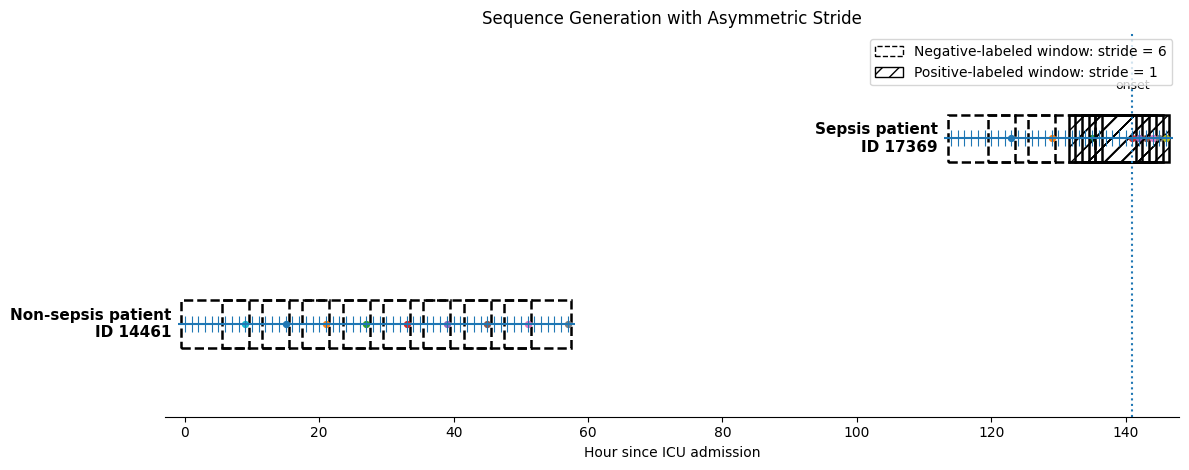

Saved: /kaggle/working/figure_sequence_generation_asymmetric_stride_real.png
Sepsis patient ID: 17369
Non-sepsis patient ID: 14461


In [46]:
# Figure: Real sequence generation with asymmetric stride

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# - positive-labeled windows use stride = 1
# - negative-labeled windows use stride = 6

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

required_cols = [
    "patient_id",
    "window_start_hour",
    "window_end_hour",
    "y_true",
    "is_sepsis_patient",
    "onset_hour"
]

missing_cols = [c for c in required_cols if c not in meta_train.columns]
assert len(missing_cols) == 0, f"Missing columns in meta_train: {missing_cols}"

# Select one real sepsis patient and one real non-sepsis patient

# Choose a sepsis patient with enough positive-labeled windows
pos_counts = (
    meta_train[(meta_train["is_sepsis_patient"] == 1) & (meta_train["y_true"] == 1)]
    .groupby("patient_id")
    .size()
    .sort_values(ascending=False)
)

assert len(pos_counts) > 0, "No sepsis patient with positive-labeled windows found."

sepsis_pid = pos_counts.index[0]

# Choose a non-sepsis patient with enough generated windows
non_counts = (
    meta_train[meta_train["is_sepsis_patient"] == 0]
    .groupby("patient_id")
    .size()
    .sort_values(ascending=False)
)

assert len(non_counts) > 0, "No non-sepsis patient found."

non_sepsis_pid = non_counts.index[0]

sepsis_windows = (
    meta_train[meta_train["patient_id"] == sepsis_pid]
    .sort_values("window_start_hour")
    .reset_index(drop=True)
)

non_sepsis_windows = (
    meta_train[meta_train["patient_id"] == non_sepsis_pid]
    .sort_values("window_start_hour")
    .reset_index(drop=True)
)

# Select a compact subset of windows around the first positive-labeled window
first_pos_idx = sepsis_windows.index[sepsis_windows["y_true"] == 1][0]

sepsis_selected = sepsis_windows.iloc[
    max(0, first_pos_idx - 3): first_pos_idx + 6
].copy()

# Select a comparable number of windows from the non-sepsis patient
non_sepsis_selected = non_sepsis_windows.head(len(sepsis_selected)).copy()

# Plot helper

def draw_patient_windows(ax, windows, y_pos, label, show_onset=False):
    start_min = int(windows["window_start_hour"].min())
    end_max = int(windows["window_end_hour"].max())

    # Draw patient timeline
    ax.hlines(y_pos, start_min - 1, end_max + 1, linewidth=1.5)

    # Draw hourly markers
    for h in range(start_min, end_max + 1):
        ax.vlines(h, y_pos - 0.06, y_pos + 0.06, linewidth=0.8)

    # Draw generated sequence windows
    for _, row in windows.iterrows():
        start = int(row["window_start_hour"])
        end = int(row["window_end_hour"])
        y_true = int(row["y_true"])

        rect = Rectangle(
            (start - 0.5, y_pos - 0.18),
            end - start + 1,
            0.36,
            fill=False,
            linewidth=1.8,
            linestyle="-" if y_true == 1 else "--",
            hatch="//" if y_true == 1 else None
        )
        ax.add_patch(rect)

        # Mark the label time step at the end of the window
        ax.scatter(end, y_pos, s=18)

    # Optional onset marker for the sepsis patient
    if show_onset:
        onset_values = windows["onset_hour"].dropna().unique()
        if len(onset_values) > 0:
            onset_hour = int(onset_values[0])
            if start_min <= onset_hour <= end_max:
                ax.axvline(onset_hour, linestyle=":", linewidth=1.5)
                ax.text(
                    onset_hour,
                    y_pos + 0.35,
                    "onset",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    ax.text(
        start_min - 2.0,
        y_pos,
        label,
        ha="right",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Draw figure

fig, ax = plt.subplots(figsize=(12, 4.8))

draw_patient_windows(
    ax,
    sepsis_selected,
    y_pos=2.2,
    label=f"Sepsis patient\nID {sepsis_pid}",
    show_onset=True
)

draw_patient_windows(
    ax,
    non_sepsis_selected,
    y_pos=0.8,
    label=f"Non-sepsis patient\nID {non_sepsis_pid}",
    show_onset=False
)

# Formatting
all_start = min(
    sepsis_selected["window_start_hour"].min(),
    non_sepsis_selected["window_start_hour"].min()
)

all_end = max(
    sepsis_selected["window_end_hour"].max(),
    non_sepsis_selected["window_end_hour"].max()
)

ax.set_xlim(all_start - 3, all_end + 2)
ax.set_ylim(0.1, 3.0)
ax.set_xlabel("Hour since ICU admission")
ax.set_yticks([])
ax.set_title("Sequence Generation with Asymmetric Stride")

legend_handles = [
    Patch(fill=False, linestyle="--", label="Negative-labeled window: stride = 6"),
    Patch(fill=False, linestyle="-", hatch="//", label="Positive-labeled window: stride = 1"),
]

ax.legend(handles=legend_handles, loc="upper right")

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(
    OUTPUT_DIR,
    "figure_sequence_generation_asymmetric_stride_real.png"
)

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("Sepsis patient ID:", sepsis_pid)
print("Non-sepsis patient ID:", non_sepsis_pid)

In [47]:
meta_train.to_csv('/kaggle/working/meta_train.csv', index=False)
meta_val.to_csv('/kaggle/working/meta_val.csv', index=False)
meta_test.to_csv('/kaggle/working/meta_test.csv', index=False)

print("Saved:")
print("- /kaggle/working/meta_train.csv")
print("- /kaggle/working/meta_val.csv")
print("- /kaggle/working/meta_test.csv")

Saved:
- /kaggle/working/meta_train.csv
- /kaggle/working/meta_val.csv
- /kaggle/working/meta_test.csv


In [48]:
print("Train positive rate:", y_train.mean())
print("Val positive rate:", y_val.mean())
print("Test positive rate:", y_test.mean())

Train positive rate: 0.0752956672063222
Val positive rate: 0.01901497402998999
Test positive rate: 0.01740848071059816


In [49]:
np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/id_train.npy', id_train)

np.save('/kaggle/working/X_val.npy', X_val)
np.save('/kaggle/working/y_val.npy', y_val)
np.save('/kaggle/working/id_val.npy', id_val)

np.save('/kaggle/working/X_test.npy', X_test)
np.save('/kaggle/working/y_test.npy', y_test)
np.save('/kaggle/working/id_test.npy', id_test)

print("Saved sequence datasets with patient ids.")

Saved sequence datasets with patient ids.
